<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/AI_prog/ML_lab2_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
cifar_10_path = kagglehub.competition_download('cifar-10')

print('Data source import complete.')


100%|██████████| 715M/715M [00:06<00:00, 115MB/s]

Extracting files...


Data source import complete.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from PIL import Image
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import pickle
import os
import torch.nn.functional as F
import requests
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sn
import pandas as pd
torch.manual_seed(1)
from sklearn import preprocessing
from torch.utils.data import DataLoader, Dataset, Subset
import torch.utils.data
mps_device = torch.device("cpu")

In [ ]:
IMAGE_SIZE = 32

mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]
composed_train = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Resize the image in a 32X32 shape
                                     transforms.RandomHorizontalFlip(0.1), # Randomly horizontal flip the images
                                     transforms.ColorJitter(brightness = 0.1,
                                                            contrast = 0.1,
                                                            saturation = 0.1),
                                     transforms.RandomAdjustSharpness(sharpness_factor = 2,
                                                                      p = 0.1), # Randomly adjust sharpness
                                     transforms.ToTensor(),   # Converting image to tensor
                                     transforms.Normalize(mean, std)])


composed_test = transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean, std)])


In [ ]:
train_dataset = dsets.CIFAR10(root='./data', train=True, download=True, transform=composed_train)
validation_dataset = dsets.CIFAR10(root='./data', train=False, download=True, transform=composed_test)
print(f"✅ Количество тестовых изображений: {len(train_dataset)}")
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=100)

100%|██████████| 170M/170M [00:03<00:00, 56.3MB/s]


✅ Количество тестовых изображений: 50000


In [ ]:
def show_data(img):
    try:
        plt.imshow(img[0])
    except Exception as e:
        print(e)
    print(img[0].shape, img[0].permute(1,2,0).shape)
    plt.imshow(img[0].permute(1,2,0))
    plt.title('y = '+ str(img[1]))
    plt.show()

def im_convert(tensor):
    img = tensor.cpu().clone().detach().numpy() #
    img = img.transpose(1, 2, 0)
    img = img.clip(0, 1)
    return img

Invalid shape (3, 32, 32) for image data
torch.Size([3, 32, 32]) torch.Size([32, 32, 3])


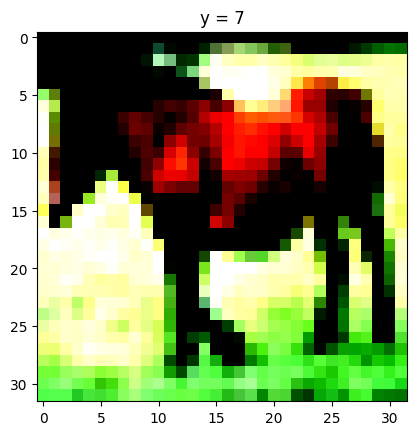

In [ ]:
show_data(train_dataset[7])

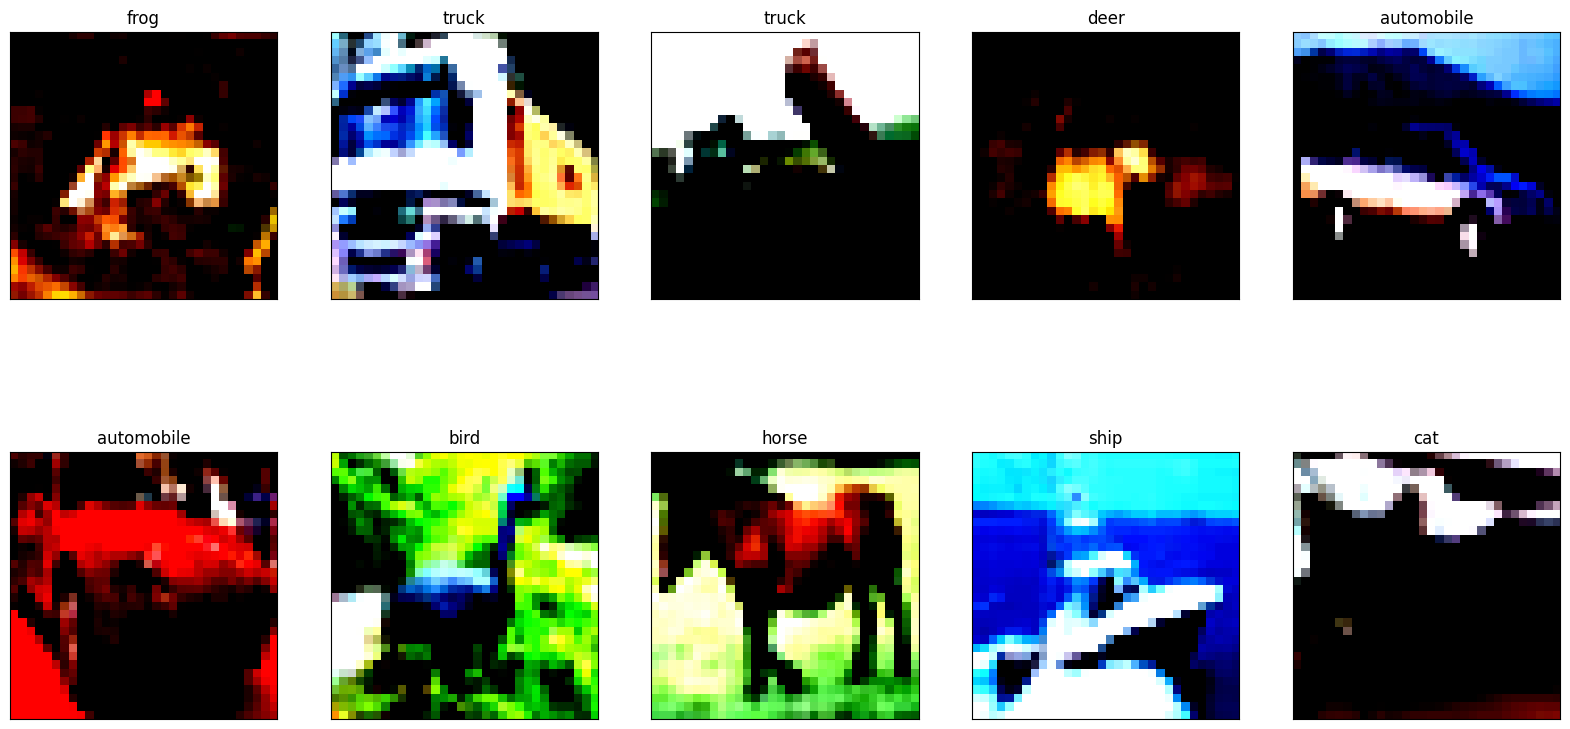

In [ ]:
classes = ('airplane',
           'automobile',
           'bird',
           'cat',
           'deer',
           'dog',
           'frog',
           'horse',
           'ship',
           'truck')

data_iterable = iter(train_loader)
images, labels = next(data_iterable)
fig = plt.figure(figsize=(20, 10))

for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    ax.set_title(classes[labels[idx].item()])

In [ ]:
def train_model(model, train_loader, validation_loader, optimizer, n_epochs = 20):
    N_test = len(validation_dataset)
    accuracy_list = []
    train_loss_list = []
    model = model.to(mps_device)
    train_cost_list = []
    val_cost_list = []

    for epoch in range(n_epochs):
        train_COST = 0
        for x,y in train_loader:
            x = x.to(mps_device)
            y = y.to(mps_device)
            model.train()
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z,y)
            loss.backward()
            optimizer.step()
            train_COST+=loss.item()

        train_COST = train_COST/len(train_loader)
        train_cost_list.append(train_COST)
        correct = 0

        val_COST = 0
        for x_test, y_test in validation_loader:
            model.eval()
            x_test = x_test.to(mps_device)
            y_test = y_test.to(mps_device)
            z = model(x_test)
            val_loss = criterion(z, y_test)
            _, yhat = torch.max(z.data, 1)
            correct += (yhat==y_test).sum().item()
            val_COST+=val_loss.item()

        val_COST = val_COST/ len(validation_loader)
        val_cost_list.append(val_COST)

        accuracy = correct / N_test
        accuracy_list.append(accuracy)

        print("--> Epoch Number : {}".format(epoch + 1),
              " | Training Loss : {}".format(round(train_COST,4)),
              " | Validation Loss : {}".format(round(val_COST,4)),
              " | Validation Accuracy : {}%".format(round(accuracy * 100, 2)))

    return accuracy_list, train_cost_list, val_cost_list

In [ ]:
class CNN_V3_V4(nn.Module):
    def __init__(self, out_1 = 32, out_2 = 64, out_3 = 128, number_of_classes = 10, p = 0):
        super(CNN_V3_V4, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels = 3, out_channels = out_1, kernel_size = 5, padding = 2)
        self.maxpool1 = nn.MaxPool2d(kernel_size = 2)
        self.conv1_bn = nn.BatchNorm2d(out_1)
        self.drop_conv = nn.Dropout(p=0.2)

        self.cnn2 = nn.Conv2d(in_channels = out_1, out_channels = out_2, kernel_size = 5, padding = 2)
        self.maxpool2 = nn.MaxPool2d(kernel_size = 2)
        self.conv2_bn = nn.BatchNorm2d(out_2)

        self.cnn3 = nn.Conv2d(in_channels = out_2, out_channels = out_3, kernel_size = 5, padding = 2)
        self.maxpool3 = nn.MaxPool2d(kernel_size = 2)
        self.conv3_bn = nn.BatchNorm2d(out_3)

        self.fc1 = nn.Linear(out_3 * 4 * 4, 1000)
        self.drop = nn.Dropout(p=p)
        self.fc1_bn = nn.BatchNorm1d(1000)

        # Hidden layer 2
        self.fc2 = nn.Linear(1000, 1000)
        self.fc2_bn = nn.BatchNorm1d(1000)

        # Hidden layer 3
        self.fc3 = nn.Linear(1000, 1000)
        self.fc3_bn = nn.BatchNorm1d(1000)

        # Hidden layer 4
        self.fc4 = nn.Linear(1000, 1000)
        self.fc4_bn = nn.BatchNorm1d(1000)

        # Final layer
        self.fc5 = nn.Linear(1000, 10)
        self.fc5_bn = nn.BatchNorm1d(10)

    # Predictiona
    def forward(self, x):

        x = self.cnn1(x)
        x = self.conv1_bn(x)
        x = self.maxpool1(x)
        x = self.drop_conv(x)

        x = self.cnn2(x)
        x = self.conv2_bn(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = self.drop_conv(x)

        x = self.cnn3(x)
        x = self.conv3_bn(x)
        x = torch.relu(x)
        x = self.maxpool3(x)
        x = self.drop_conv(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc1_bn(x)

        x = F.relu(self.drop(x))
        x = self.fc2(x)
        x = self.fc2_bn(x)

        x = F.relu(self.drop(x))
        x = self.fc3(x)
        x = self.fc3_bn(x)

        x = F.relu(self.drop(x))
        x = self.fc4(x)
        x = self.fc4_bn(x)

        x = F.relu(self.drop(x))
        x = self.fc5(x)
        x = self.fc5_bn(x)

        return(x)

In [ ]:
model_mmtv5 = CNN_V3_V4(out_1=32, out_2=64, out_3 =128, number_of_classes = 10, p=0.5)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model_mmtv5.parameters(), lr = learning_rate, momentum = 0.2)

accuracy_list_normalv5, train_cost_listv5, val_cost_listv5=train_model(model=model_mmtv5, n_epochs=25, train_loader=train_loader, validation_loader=validation_loader, optimizer=optimizer)

--> Epoch Number : 1  | Training Loss : 1.6174  | Validation Loss : 1.2382  | Validation Accuracy : 55.64%
--> Epoch Number : 2  | Training Loss : 1.2642  | Validation Loss : 1.0685  | Validation Accuracy : 62.05%
--> Epoch Number : 3  | Training Loss : 1.1002  | Validation Loss : 0.9312  | Validation Accuracy : 67.25%
--> Epoch Number : 4  | Training Loss : 0.9945  | Validation Loss : 0.8479  | Validation Accuracy : 70.85%
--> Epoch Number : 5  | Training Loss : 0.9217  | Validation Loss : 0.7783  | Validation Accuracy : 73.22%
--> Epoch Number : 6  | Training Loss : 0.8634  | Validation Loss : 0.7201  | Validation Accuracy : 75.46%
--> Epoch Number : 7  | Training Loss : 0.8196  | Validation Loss : 0.6832  | Validation Accuracy : 76.61%
--> Epoch Number : 8  | Training Loss : 0.7798  | Validation Loss : 0.6811  | Validation Accuracy : 76.74%
--> Epoch Number : 9  | Training Loss : 0.7412  | Validation Loss : 0.6805  | Validation Accuracy : 77.03%
--> Epoch Number : 10  | Training Los

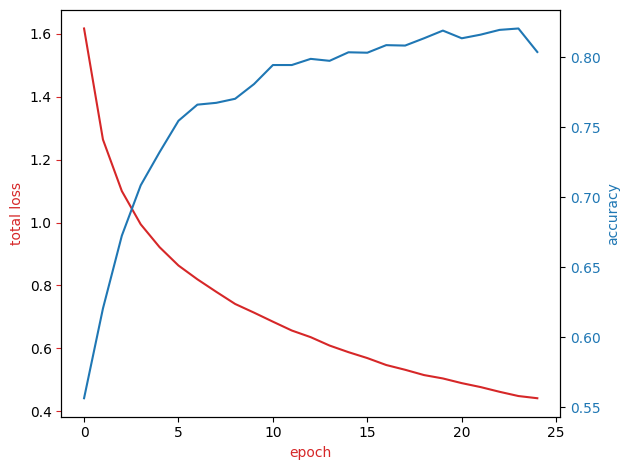

In [ ]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(train_cost_listv5,color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list_normalv5, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()

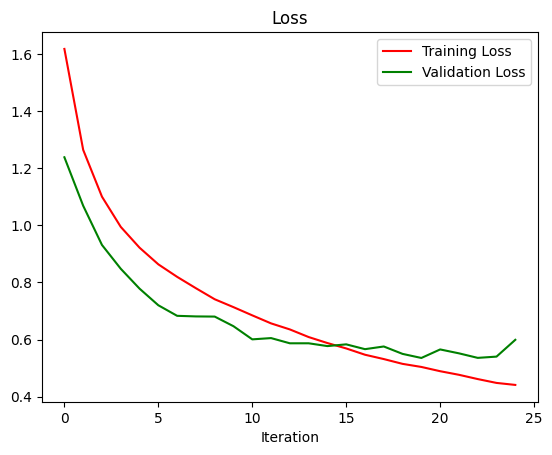

In [ ]:
plt.plot(train_cost_listv5, 'r', label='Training Loss')
plt.plot(val_cost_listv5,  'g',  label='Validation Loss')
plt.xlabel("Iteration")
plt.title("Loss")
plt.legend()

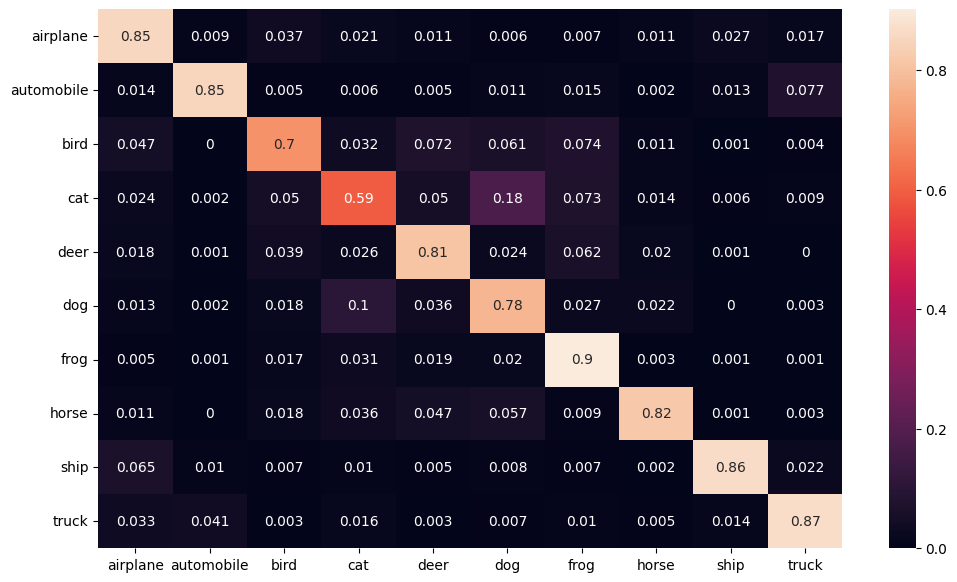

In [ ]:
y_pred = []
y_true = []

for x, y in torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=1):
    x = x.to(mps_device)
    y = y.to(mps_device)
    z = model_mmtv5(x)
    _, yhat = torch.max(z, 1)
    pred = yhat.data.cpu().numpy()
    y_pred.extend(pred)
    labels = y.data.cpu().numpy()
    y_true.extend(labels)

cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix/np.sum(cf_matrix) *10, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output.png')

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1000
           1       0.93      0.85      0.89      1000
           2       0.78      0.70      0.74      1000
           3       0.68      0.59      0.63      1000
           4       0.77      0.81      0.79      1000
           5       0.68      0.78      0.72      1000
           6       0.76      0.90      0.83      1000
           7       0.90      0.82      0.86      1000
           8       0.93      0.86      0.90      1000
           9       0.86      0.87      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



Invalid shape (3, 32, 32) for image data
torch.Size([3, 32, 32]) torch.Size([32, 32, 3])


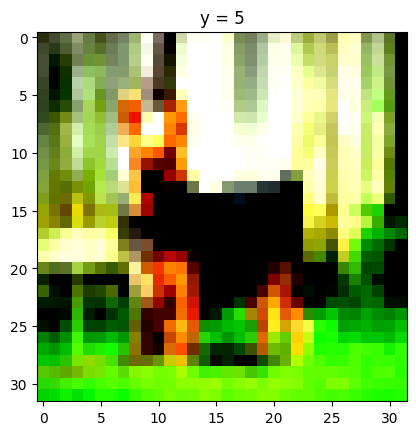

yhat:  tensor([4])


Invalid shape (3, 32, 32) for image data
torch.Size([3, 32, 32]) torch.Size([32, 32, 3])


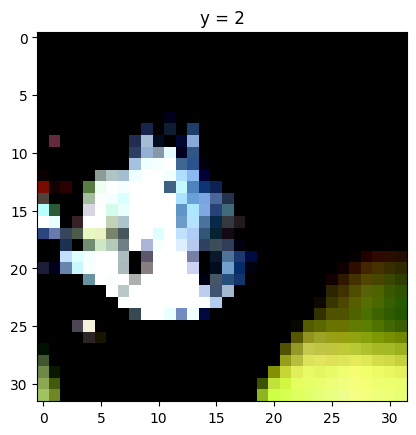

yhat:  tensor([8])
Invalid shape (3, 32, 32) for image data
torch.Size([3, 32, 32]) torch.Size([32, 32, 3])


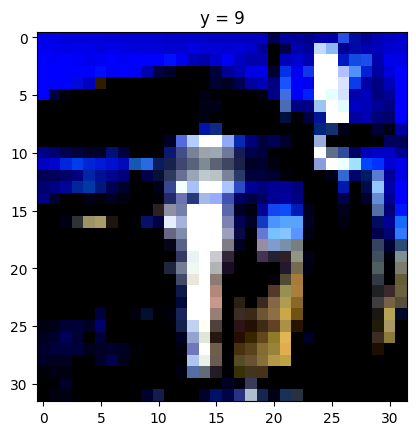

yhat:  tensor([8])


In [ ]:
count = 0
i = 0
for x, y in torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=1):
    x = x.to(mps_device)
    y = y.to(mps_device)
    z = model_mmtv5(x)
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data(validation_dataset[i])
        plt.show()
        print("yhat: ",yhat)
        count += 1
    if count >= 3:
        break
    i+=1

In [ ]:
data_iterable = iter(validation_dataset)
images, labels = next(data_iterable)
images = images.to(mps_device)
labels = labels.to(mps_device)
output = model_mmtv5(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 15))

for idx in np.arange(50):
    ax = fig.add_subplot(5, 10, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    ax.set_title("{} ({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
                 color=("green" if preds[idx]==labels[idx] else "red"))

In [ ]:
class TestImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_dir + '/' + str(self.img_labels.iloc[idx, 0]) +'.png'

        image = np.asarray(Image.open(img_path).convert('RGB'))

        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [ ]:
composed_test_check = transforms.Compose([transforms.ToPILImage(),
                                          transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
                                          transforms.ToTensor(),
                                          transforms.Normalize(mean, std)])

SUBMISSION = os.path.join(os.getcwd(),"data/submission_cnn.csv")
test_dataset = TestImageDataset(annotations_file=SUBMISSION, img_dir='./data/test', transform=composed_test_check)
test_loader = DataLoader(dataset=test_dataset, batch_size=500, shuffle=False)

submit_df = pd.read_csv(SUBMISSION)

label_encoder = preprocessing.LabelEncoder()
label_encoder.fit_transform(list(classes))

model_mmtv5 = model_mmtv5.to(mps_device)
i = 0
y_test_pred_list = []

for X_test, _ in torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1000):
    X_test = X_test.to(mps_device)
    model_mmtv5.eval()
    _, y_test_pred = torch.max(model_mmtv5(X_test), 1)
    y_test_pred = y_test_pred.cpu()

    y_test_pred = label_encoder.inverse_transform(y_test_pred)
    y_test_pred_list.extend(y_test_pred)

submit_df['label'] = y_test_pred_list


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


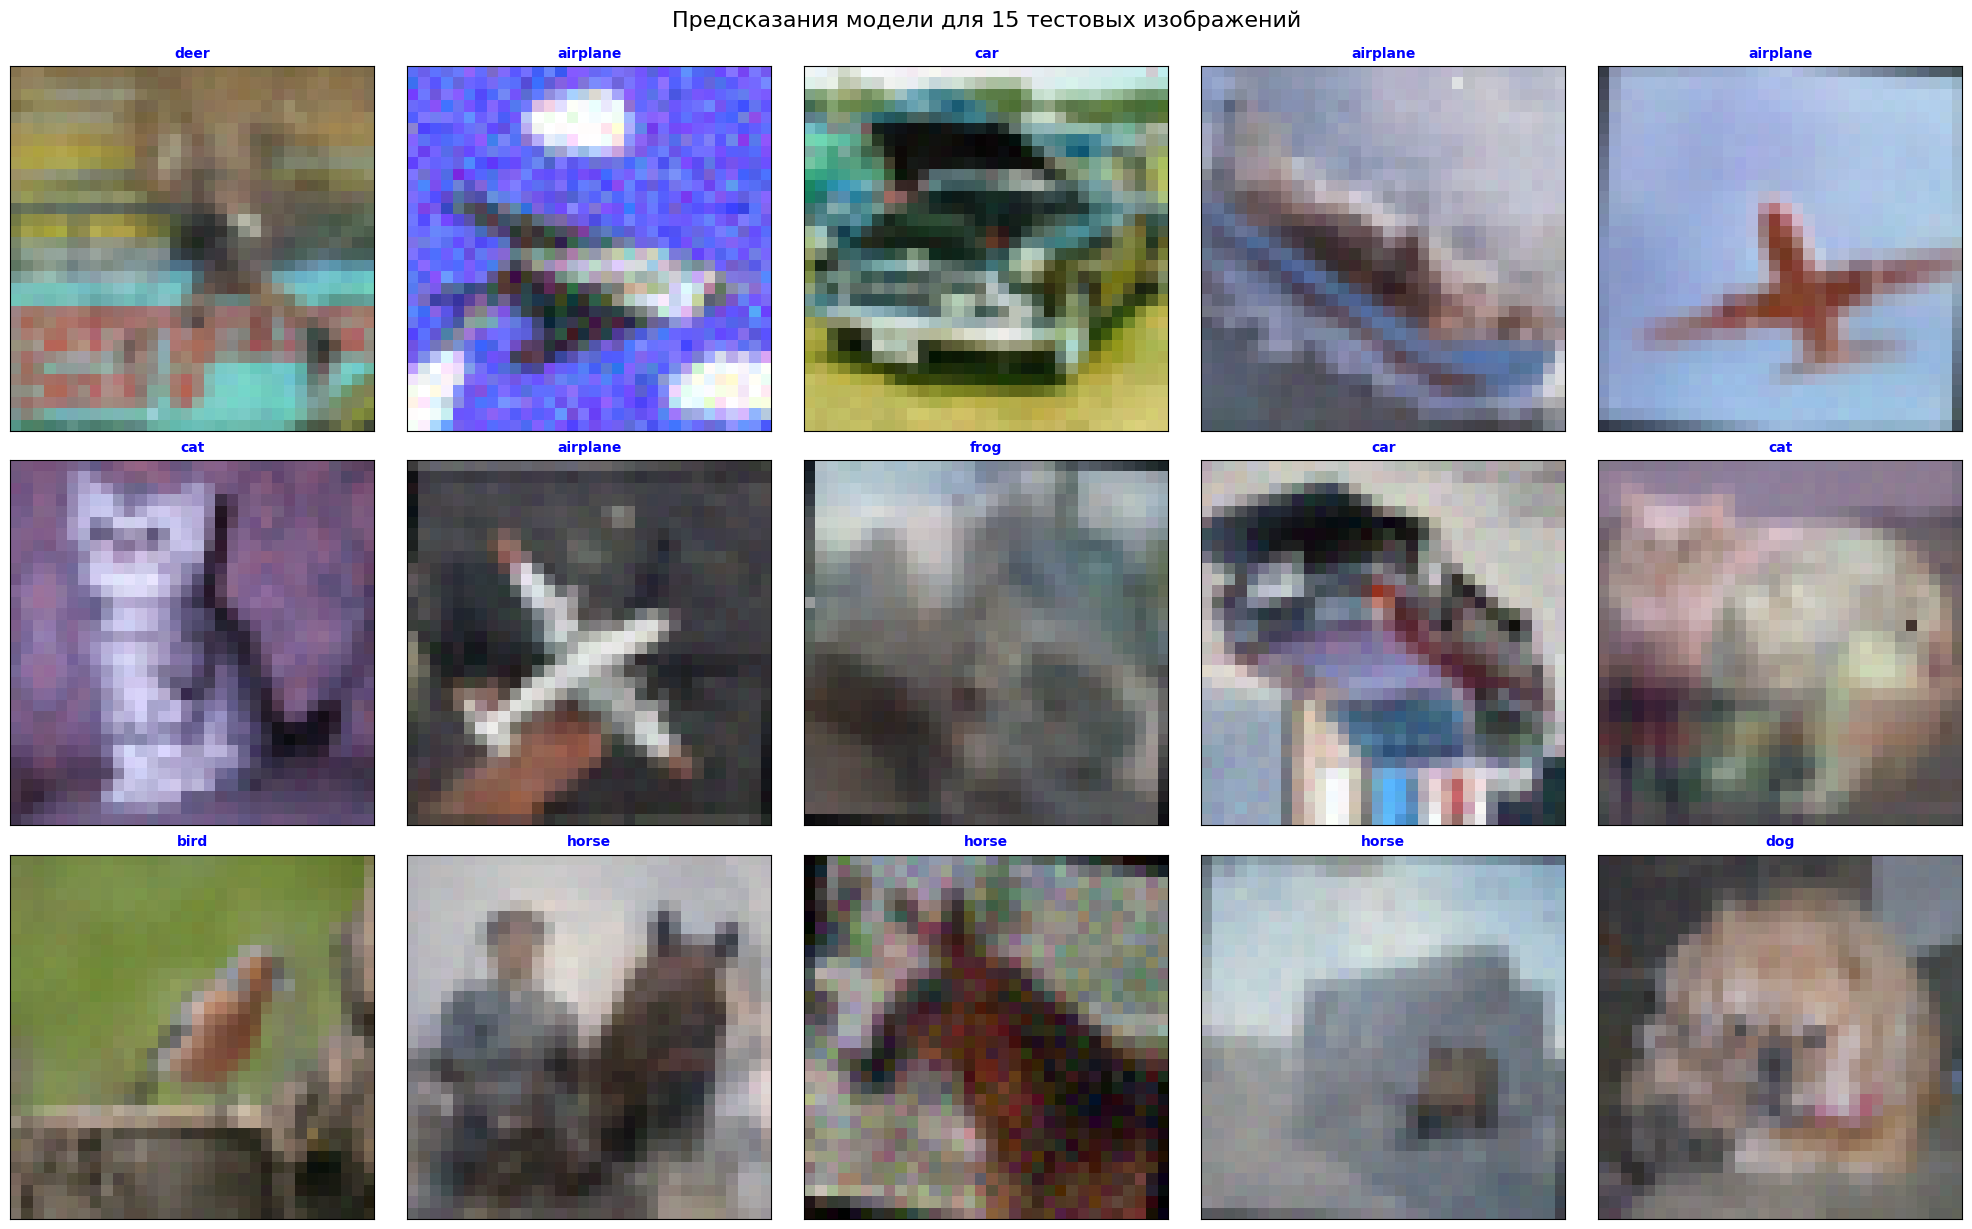

In [ ]:
CSV_FILE = 'submission_cnn.csv'
NUM_IMAGES_TO_SHOW = 50
ROWS = 5
COLS = NUM_IMAGES_TO_SHOW // ROWS

submit_df = pd.read_csv(CSV_FILE)

num_to_show = min(NUM_IMAGES_TO_SHOW, len(submit_df))

fig = plt.figure(figsize=(COLS * 4, ROWS * 4))

for idx in range(num_to_show):
    row_idx = idx // COLS
    col_idx = idx % COLS

    img_id = str(submit_df.iloc[idx, 0])
    pred_label = submit_df.iloc[idx, 1]

    img_filename = f"{img_id}_noisy.png"
    img_path = os.path.join(test_dataset, img_filename)

    img = Image.open(img_path).convert('RGB')
    ax = fig.add_subplot(ROWS, COLS, idx + 1, xticks=[], yticks=[])
    plt.imshow(img)
    ax.set_title(f"{pred_label}", color="blue", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle(f"Предсказания модели для {num_to_show} тестовых изображений", fontsize=16, y=1.02)
plt.show()